1.   Using the body_mass_g column from the Palmer Penguins dataset, demonstrate the
effect of an outlier by adding an extreme value, compare the mean and median before
and after the outlier, and write your observations based on the `results in your own
words as comments.

In [2]:
import seaborn as sns
penguins_df = sns.load_dataset('penguins')
import pandas as pd


In [3]:
mean_bef = penguins_df["body_mass_g"].mean()
median_bef = penguins_df["body_mass_g"].median()

print(f"mean before {mean_bef}")
print(f"median before {median_bef}")

''' mean here is around 4201 and meidan is 4050'''

mean before 4201.754385964912
median before 4050.0


' mean here is around 4201 and meidan is 4050'

In [4]:

outlier_row = penguins_df.iloc[[0]].copy()
outlier_row["body_mass_g"] = 50000
peng_outlier_df = pd.concat([penguins_df,outlier_row],ignore_index = True)

In [5]:
print(peng_outlier_df.shape)
print(peng_outlier_df.tail())

mean_aft = peng_outlier_df["body_mass_g"].mean()
median_aft = peng_outlier_df["body_mass_g"].median()

print(f"mean after {mean_aft}")
print(f"median after {median_aft}")

''' mean here is around 4335 a difreence of around 100 units whereas median is same 4050'''

(345, 7)
    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
340  Gentoo     Biscoe            46.8           14.3              215.0   
341  Gentoo     Biscoe            50.4           15.7              222.0   
342  Gentoo     Biscoe            45.2           14.8              212.0   
343  Gentoo     Biscoe            49.9           16.1              213.0   
344  Adelie  Torgersen            39.1           18.7              181.0   

     body_mass_g     sex  
340       4850.0  Female  
341       5750.0    Male  
342       5200.0  Female  
343       5400.0    Male  
344      50000.0    Male  
mean after 4335.276967930029
median after 4050.0


' mean here is around 4335 a difreence of around 100 units whereas median is same 4050'

Using the flipper_length_mm column from the Palmer Penguins dataset, create
histograms to compare the distribution of flipper lengths across different penguin
species, and write your observations based on the visualization and results in your own
words as comments.

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

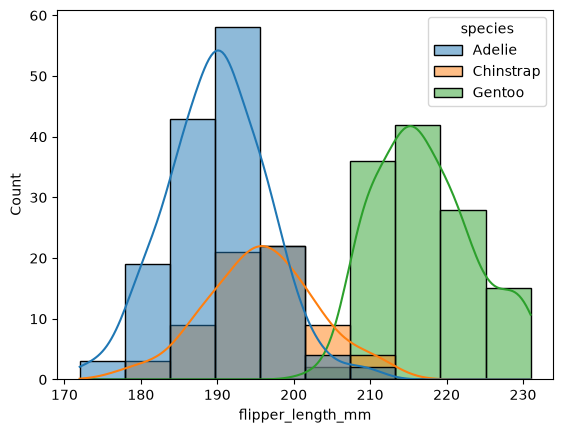

In [6]:
import matplotlib.pyplot as plt
sns.histplot ( 
    data = penguins_df,
    x = "flipper_length_mm",
    hue = "species",
    multiple = "layer",
    kde = True,
    alpha=0.5
    )




<Axes: xlabel='flipper_length_mm', ylabel='Count'>

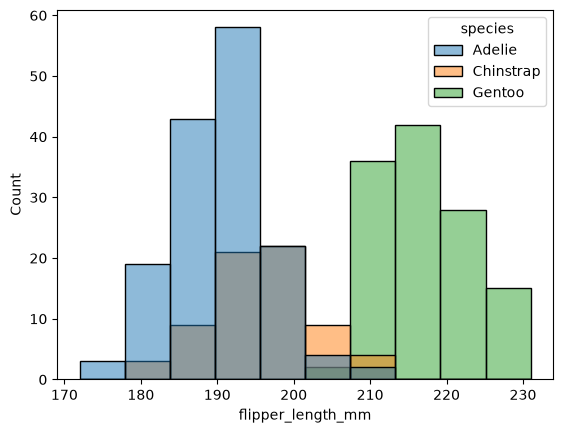

In [7]:
sns.histplot(
    data = penguins_df,
    x = "flipper_length_mm",
    hue = "species",
    multiple = "layer" ,
)

3.      Using the body_mass_g column from the Palmer Penguins dataset, compare the
distribution of body mass across different penguin species by calculating the variance,
skewness, kurtosis, and Pearson's coefficients of skewness, and write your observations
based on the results in your own words as comments.

Minimum: 2700.0
Q1: 3550.0
Median: 4050.0
Q3: 4750.0
Maximum: 6300.0
IQR: 1200.0


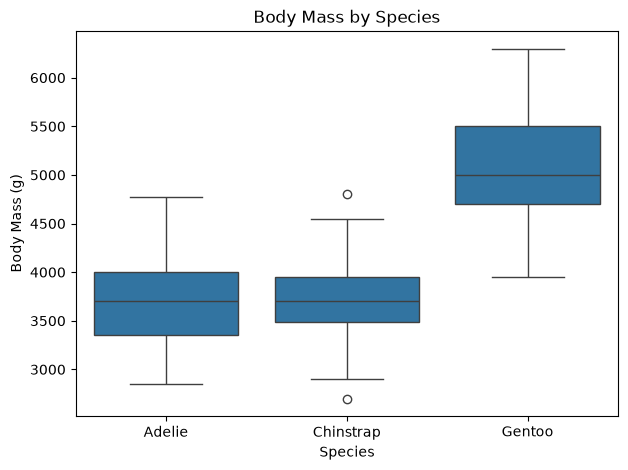

In [9]:
import seaborn as sns
from scipy import stats

penguins_df = sns.load_dataset('penguins')
penguins_df = penguins_df.dropna(subset=['body_mass_g'])

results = penguins_df.groupby('species')['body_mass_g'].agg(
    mean='mean',
    median='median',
    std='std',
    variance='var',
    skewness=lambda x: stats.skew(x),
    kurtosis=lambda x: stats.kurtosis(x)
)

results['pearson_skew_coeff'] = 3 * (results['mean'] - results['median']) / results['std']

print(results)

# Observation: Gentoo has the highest variance (heaviest, most spread out), while skewness/kurtosis close to 0 for most species suggests fairly symmetric, normal-like body mass distributions.

4. Using the body_mass_g column from the Palmer Penguins dataset, calculate the five-
number summary (minimum, Q1, median, Q3, and maximum), determine the

interquartile range (IQR), create grouped boxplots for each penguin species, and write
your observations based on the visualization and results in your own words as
comments.

Minimum: 2700.0
Q1: 3550.0
Median: 4050.0
Q3: 4750.0
Maximum: 6300.0
IQR: 1200.0


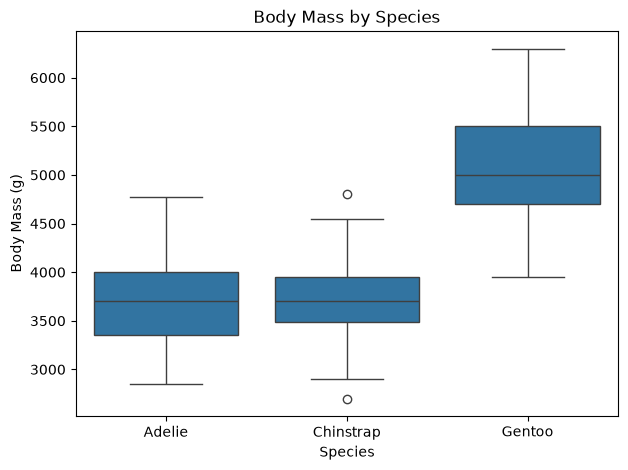

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

penguins_df = sns.load_dataset('penguins')
penguins_df = penguins_df.dropna(subset=['body_mass_g'])

minimum = penguins_df['body_mass_g'].min()
q1 = penguins_df['body_mass_g'].quantile(0.25)
median = penguins_df['body_mass_g'].median()
q3 = penguins_df['body_mass_g'].quantile(0.75)
maximum = penguins_df['body_mass_g'].max()
iqr = q3 - q1

print("Minimum:", minimum)
print("Q1:", q1)
print("Median:", median)
print("Q3:", q3)
print("Maximum:", maximum)
print("IQR:", iqr)

plt.figure(figsize=(7,5))
sns.boxplot(data=penguins_df, x='species', y='body_mass_g')
plt.title('Body Mass by Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()

# Observation: Gentoo penguins have the highest body mass and IQR, while Adelie and Chinstrap have similar, lower body mass with more overlap.

5.  Using the flipper_length_mm and body_mass_g columns from the Palmer Penguins
dataset, create a scatter plot, fit a linear regression line, calculate the covariance and
Pearson correlation coefficient, and write your observations based on the visualization
and results in your own words as comments.

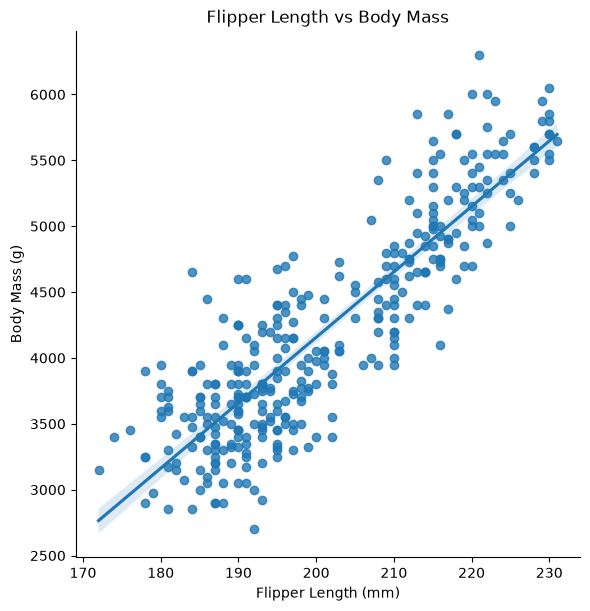

Covariance: 9824.416062149507
Correlation: 0.8712017673060112


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

penguins_df = sns.load_dataset('penguins')
penguins_df = penguins_df.dropna(subset=['flipper_length_mm', 'body_mass_g'])

sns.lmplot(data=penguins_df, x='flipper_length_mm', y='body_mass_g', height=6)
plt.title('Flipper Length vs Body Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

covariance = penguins_df['flipper_length_mm'].cov(penguins_df['body_mass_g'])
print("Covariance:", covariance)

correlation = penguins_df['flipper_length_mm'].corr(penguins_df['body_mass_g'])
print("Correlation:", correlation)

# Observation: Positive covariance and a correlation close to 1 show flipper length and body mass are strongly related - longer flippers mean heavier penguins.

6.     Using the body_mass_g column from the Palmer Penguins dataset, group the data based
on the island column and calculate the total penguin biomass supported by each island.
Create a pie chart to show the proportion of total biomass contributed by each island
and a bar chart to compare the absolute total biomass values. Write your observations
based on the visualization and results in your own words as comments.

island
Biscoe       787575.0
Dream        460400.0
Torgersen    189025.0
Name: body_mass_g, dtype: float64


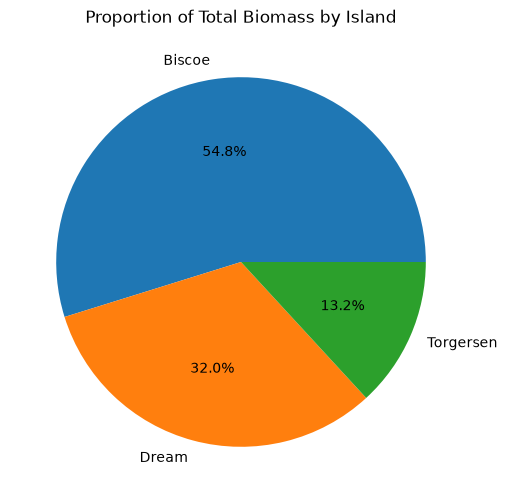

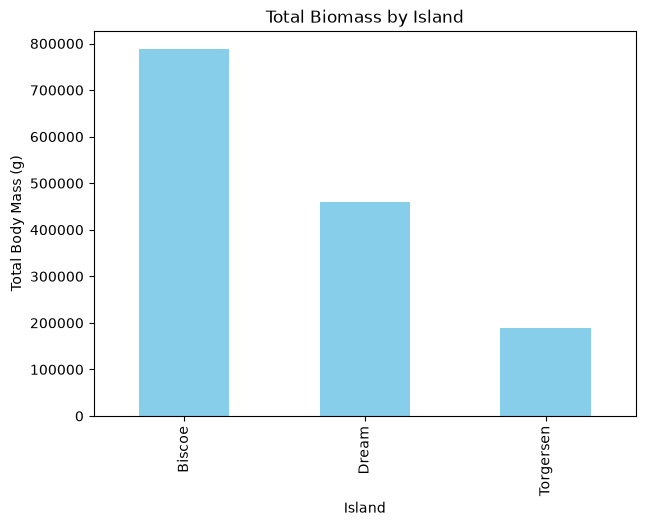

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

penguins_df = sns.load_dataset('penguins')
penguins_df = penguins_df.dropna(subset=['body_mass_g'])

biomass_by_island = penguins_df.groupby('island')['body_mass_g'].sum()
print(biomass_by_island)

plt.figure(figsize=(6,6))
plt.pie(biomass_by_island, labels=biomass_by_island.index, autopct='%1.1f%%')
plt.title('Proportion of Total Biomass by Island')
plt.show()

plt.figure(figsize=(7,5))
biomass_by_island.plot(kind='bar', color='skyblue')
plt.title('Total Biomass by Island')
plt.xlabel('Island')
plt.ylabel('Total Body Mass (g)')
plt.show()

# Observation: Biscoe island has the highest total biomass, mainly because most Gentoo penguins (the heaviest species) live there.

7.    Using the bill_length_mm and bill_depth_mm columns from the Palmer Penguins
dataset, investigate whether the relationship between bill length and bill depth varies
across different penguin species. Create a scatter plot with different colors representing
each species to identify species-specific patterns and relationships. Write your
observations based on the visualization and results in your own words as comments.

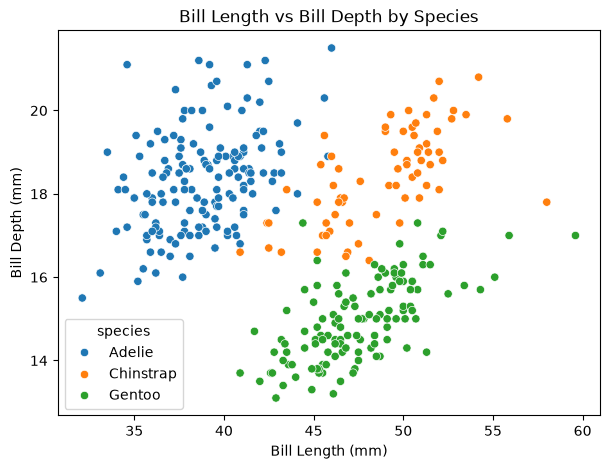

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

penguins_df = sns.load_dataset('penguins')
penguins_df = penguins_df.dropna(subset=['bill_length_mm', 'bill_depth_mm'])

plt.figure(figsize=(7,5))
sns.scatterplot(data=penguins_df, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title('Bill Length vs Bill Depth by Species')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.show()

# Observation: Bill length and depth increase together within each species, but Gentoo forms a separate cluster with longer, shallower bills.

1.    Using the Price column from the Dow Jones dataset, calculate the five-number
summary (minimum, Q1, median, Q3, and maximum) and determine the interquartile
range (IQR). Group the data using the engineered Decade column and create boxplots
to compare the distribution, spread, and median price values across different decades.
Write your observations based on the visualization and results in your own words as
comments.

Minimum: 46.85
Q1: 106.9
Median: 172.27
Q3: 436.73
Maximum: 985.93
IQR: 329.83000000000004


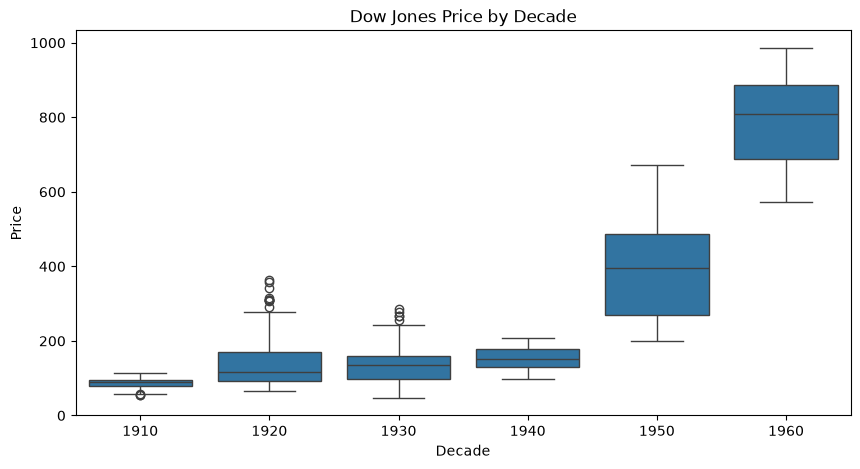

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

dowjones_df = sns.load_dataset('dowjones')

# Five number summary for Price
minimum = dowjones_df['Price'].min()
q1 = dowjones_df['Price'].quantile(0.25)
median = dowjones_df['Price'].median()
q3 = dowjones_df['Price'].quantile(0.75)
maximum = dowjones_df['Price'].max()
iqr = q3 - q1

print("Minimum:", minimum)
print("Q1:", q1)
print("Median:", median)
print("Q3:", q3)
print("Maximum:", maximum)
print("IQR:", iqr)

# Engineer a Decade column from the Date column
dowjones_df['Date'] = pd.to_datetime(dowjones_df['Date'])
dowjones_df['Decade'] = (dowjones_df['Date'].dt.year // 10) * 10

# Boxplot grouped by Decade
plt.figure(figsize=(10,5))
sns.boxplot(data=dowjones_df, x='Decade', y='Price')
plt.title('Dow Jones Price by Decade')
plt.xlabel('Decade')
plt.ylabel('Price')
plt.show()

# Observation: Price and spread clearly increase in later decades, showing the index grew a lot over time along with more variation.

2.             Using the Date and Price columns from the Dow Jones dataset, create a time-series line
plot to visualize the change in index prices over time. Convert dates into numerical
values and fit a linear regression model to identify the overall trend in the data. Display
the regression trendline along with the original time-series data, calculate the Pearson
correlation coefficient and R-squared value, and write your observations based on the
visualization and results in your own words as comments.

Correlation: 0.8263536194947423
R-squared: 0.6828603044520614


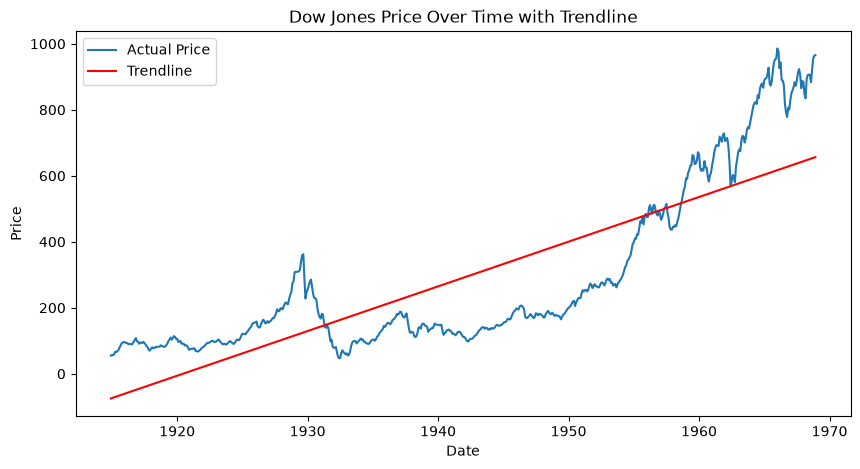

In [17]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

dowjones_df = sns.load_dataset('dowjones')
dowjones_df['Date'] = pd.to_datetime(dowjones_df['Date'])

# Convert dates into numbers (days since the first date) so we can fit regression
dowjones_df['Date_num'] = (dowjones_df['Date'] - dowjones_df['Date'].min()).dt.days

# Linear regression: Date_num vs Price
slope, intercept, r_value, p_value, std_err = stats.linregress(dowjones_df['Date_num'], dowjones_df['Price'])

# Predicted trendline values
dowjones_df['trend'] = slope * dowjones_df['Date_num'] + intercept

# Pearson correlation coefficient and R-squared
correlation = r_value
r_squared = r_value ** 2

print("Correlation:", correlation)
print("R-squared:", r_squared)

# Plot original data with trendline
plt.figure(figsize=(10,5))
plt.plot(dowjones_df['Date'], dowjones_df['Price'], label='Actual Price')
plt.plot(dowjones_df['Date'], dowjones_df['trend'], color='red', label='Trendline')
plt.title('Dow Jones Price Over Time with Trendline')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Observation: A strong positive correlation and high R-squared show the Dow Jones price has a clear upward trend over time, though it doesn't move up in a straight, smooth line.